### Structured Output
Models can be requested to provide their response in a format matching a given schema. This is useful for ensuring the output can be easily parsed and used in subsequent processing. LangChain supports multiple schema types and methods for enforcing structured output.

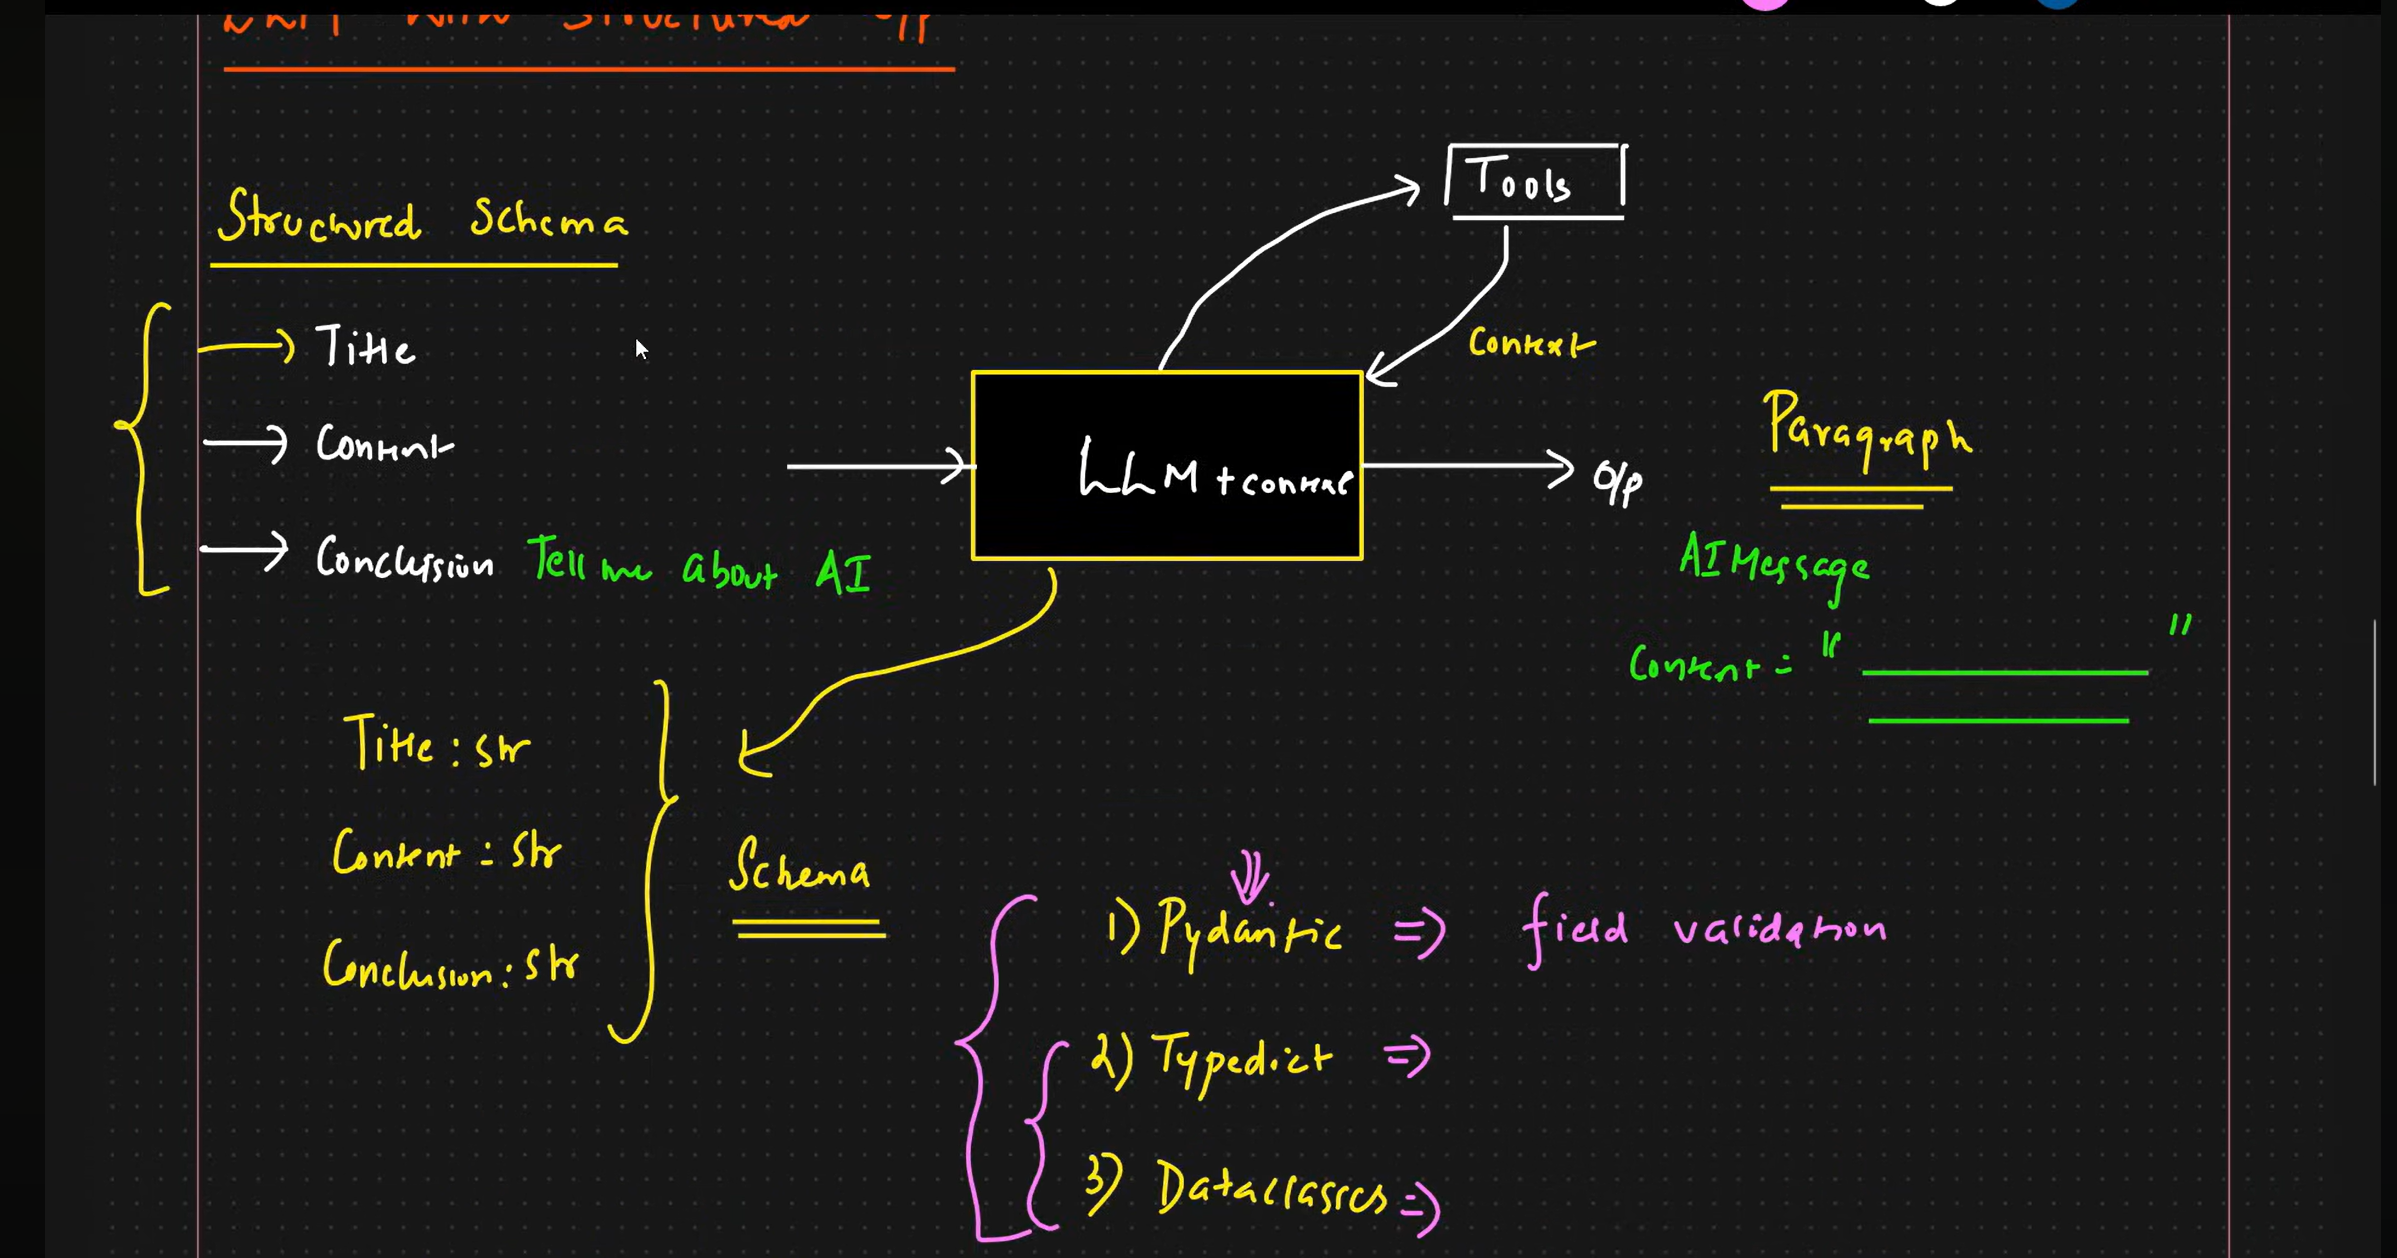

We basically uses *3 Data Structures** to create Structured Schema:
1. Pydantic
2. TypedDict
3. Dataclasses

**NOTE**: Here, the pydantic has a special feature called as **field validation** which restricts the LLM to provide only the required format or else it throughs **validation error**.

### Pydantic
Pydantic models provide the richest feature set with field validation, descriptions, and nested structures.

In [4]:
# Import the model

import os
from langchain.chat_models import init_chat_model

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
model = init_chat_model("groq:qwen/qwen3-32b")
model


ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000247B801E210>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000247B801EC10>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [5]:
# Create the schema

from pydantic import BaseModel,Field

class Movie(BaseModel): # We have inherited the Base Model into Movie due to which Variables in Movie will now be validated. 
    title:str=Field(description="The title of the movie")
    year:int=Field(description="The year the movie was released")
    director:str=Field(description="The director of the movie")
    rating:float=Field(description="The movie rating out of 10")

In [7]:
# Attach the schema to the model

model_with_structure = model.with_structured_output(Movie)
model_with_structure

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000247B801E210>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000247B801EC10>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'description': '', 'parameters': {'properties': {'title': {'description': 'The title of the movie', 'type': 'string'}, 'year': {'description': 'The year the movie was released', 'type': 'integer'}, 'director': {'description': 'The director of the movie', 'type': 'string'}, 'rating': {'description': 'The movie rating out o

In [8]:
# first, see the normal output
model.invoke("Provide the details about the movie Inception")

AIMessage(content='<think>\nOkay, so I need to provide details about the movie Inception. Let me start by recalling what I know about it. It\'s a science fiction movie directed by Christopher Nolan, right? The main actor is Leonardo DiCaprio. The title "Inception" makes me think it\'s about planting ideas, maybe something like that. The plot probably involves dreams or something where you enter someone\'s mind.\n\nWait, I think the main character is a thief who can steal secrets by entering people\'s subconscious. But in the movie, he\'s supposed to do the opposite: plant an idea instead of stealing. That\'s the inception part. The cast includes some big names like Joseph Gordon-Levitt, Elliot Page, and Tom Hardy. The music is by Hans Zimmer, which gives it that intense score.\n\nThe setting is probably in a near-future world where technology allows people to enter dreams. There\'s a concept called the "kick," which I think is a way to wake up from a dream. There\'s also a totem, like 

In [9]:
# now, with structured output
model_with_structure.invoke("Provide the details about the movie Inception")

Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8)

#### Message output alongside Parsed structure using Pydantic
This will give the output with the Raw (AIMessage) and Parsed (Structured Schema).

In [10]:
from pydantic import BaseModel,Field

class Movie(BaseModel): 
    title:str=Field(description="The title of the movie")
    year:int=Field(description="The year the movie was released")
    director:str=Field(description="The director of the movie")
    rating:float=Field(description="The movie rating out of 10")

model_with_structure = model.with_structured_output(Movie, include_raw=True)

response = model_with_structure.invoke("Provide details about the movie Inception")
response

{'raw': AIMessage(content='', additional_kwargs={'reasoning_content': "Okay, the user is asking for details about the movie Inception. Let me check the tools provided. There's a Movie function that requires title, year, director, and rating. I need to fill those parameters. I remember Inception was directed by Christopher Nolan. The release year was 2010. The rating is a bit tricky, but I think it's around 8.8 on IMDb. Let me confirm that. Yes, the IMDb rating is 8.8. So I should structure the tool call with these details. Make sure all required fields are included and the types are correct. The title is a string, year is integer, director is a string, and rating is a number. Everything looks good. Let me put that into the JSON format as specified.\n", 'tool_calls': [{'id': 'qq5jjn5vh', 'function': {'arguments': '{"director":"Christopher Nolan","rating":8.8,"title":"Inception","year":2010}', 'name': 'Movie'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens'

#### Nested Structure

In [11]:
from pydantic import BaseModel,Field

class Actor(BaseModel):
    name:str
    role:str 

class MovieDetails(BaseModel):
    title:str
    year:int
    cast:list[Actor]  # Nested the Actor class as list of Actors
    genres:list[str]
    budget:float | None = Field(None, description="Budget in million USD")

In [12]:
model_with_structure = model.with_structured_output(MovieDetails)

response = model_with_structure.invoke("Provide details about the movie Inception")
response

MovieDetails(title='Inception', year=2010, cast=[Actor(name='Leonardo DiCaprio', role='Dom Cobb'), Actor(name='Joseph Gordon-Levitt', role='Arthur'), Actor(name='Ellen Page', role='Ariadne'), Actor(name='Tom Hardy', role='Eames')], genres=['Action', 'Science Fiction', 'Heist'], budget=160.0)

### TypedDict
TypedDict provides a simpler alternative using Python's built-in typing, ideal when you don't need runtime validation.

**Note:** The runtime validation means, the output should have variable with the same structure (str, int, float) which is specified in the Schema.

In [14]:
# import 
from typing_extensions import TypedDict,Annotated

In [16]:
class MovieDict(TypedDict): 
    title: Annotated[str, ..., "The title of the movie"]
    year: Annotated[int, ..., "The year the movie was released"]
    director: Annotated[str, ..., "The director of the movie"]
    rating: Annotated[float, ..., "The movie rating out of 10"]

Note: "..." refers to the default parameters 

In [17]:
model_with_typedict = model.with_structured_output(MovieDict)

response = model_with_typedict.invoke("Provide details about the movie Inception")
response

{'director': 'Christopher Nolan',
 'rating': 8.8,
 'title': 'Inception',
 'year': 2010}

Here, we can see that their is no runtime validation and we are getting the exact value generated in any field and that is in Dictionary format. 

#### Example with respect to Structured output

In [18]:
class Actor(TypedDict):
    name:str
    role:str 

class MovieDetails(TypedDict):
    title:str
    year:int
    cast:list[Actor]  # Nested the Actor class as list of Actors
    genres:list[str]
    budget:float | None = Field(None, description="Budget in million USD")

model_with_structure = model.with_structured_output(MovieDetails)

response = model_with_structure.invoke("Provide details about the movie Inception")
response

{'budget': 160000000,
 'cast': [{'name': 'Leonardo DiCaprio', 'role': 'Dom Cobb'},
  {'name': 'Joseph Gordon-Levitt', 'role': 'Arthur'},
  {'name': 'Ellen Page', 'role': 'Ariadne'},
  {'name': 'Tom Hardy', 'role': 'Eames'}],
 'genres': ['Science Fiction', 'Action', 'Thriller'],
 'title': 'Inception',
 'year': 2010}

In [19]:
model.profile

{'max_input_tokens': 131072,
 'max_output_tokens': 16384,
 'image_inputs': False,
 'audio_inputs': False,
 'video_inputs': False,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': True,
 'tool_calling': True}

### DataClasses
A data class is a class typically containing mainly data, although there aren’t really any restrictions. You create it using the @dataclass decorator

### Structured output with Agents

In [20]:
import os
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY")

In [27]:
## Pydantic
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

class ContactInfo(BaseModel):
    """Contact information for a person.""" 
    name: str = Field(description="The name of the person")
    email: str = Field(description="The email address of the person")
    phone: str = Field(description="The phone number of the person")

model = ChatGoogleGenerativeAI(model = "gemini-2.5-flash-lite")


agent = create_agent(
    model = model,
    response_format = ContactInfo # Auto-selects provider strategy
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-456"}]
})

result

{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-456', additional_kwargs={}, response_metadata={}, id='167c9633-6fb4-49db-94f2-54da800f586b'),
  AIMessage(content='{\n  "name": "John Doe",\n  "email": "john@example.com",\n  "phone": "(555) 123-456"\n}', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5ebb-e720-7d23-a769-c0c439a2c2cf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 28, 'output_tokens': 43, 'total_tokens': 71, 'input_token_details': {'cache_read': 0}})],
 'structured_response': ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-456')}

In [28]:
result["structured_response"]

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-456')

In [29]:
## TypedDict
from typing_extensions import TypedDict
from langchain.agents import create_agent

class ContactInfo(TypedDict):
    """Contact information for a person.""" 
    name: str # The name of the person
    email: str # The email address of the person
    phone: str # The phone number of the person

agent = create_agent(
    model = model,
    response_format = ContactInfo # Auto-selects provider strategy
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-456"}]
})

result

{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-456', additional_kwargs={}, response_metadata={}, id='83d61206-86b1-4569-bac9-608a1afcdce5'),
  AIMessage(content='{\n  "name": "John Doe",\n  "email": "john@example.com",\n  "phone": "(555) 123-456"\n}', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5ebf-2070-7fb0-87ce-a8e45f87703d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 28, 'output_tokens': 43, 'total_tokens': 71, 'input_token_details': {'cache_read': 0}})],
 'structured_response': {'name': 'John Doe',
  'email': 'john@example.com',
  'phone': '(555) 123-456'}}

In [30]:
result["structured_response"]
# {'name': 'John Doe', 'email': 'john@example', 'phone': '(555) 123-456'}

{'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-456'}

In [31]:
## DataClass
from dataclasses import dataclass
from langchain.agents import create_agent

@dataclass
class ContactInfo:
    """Contact information for a person."""
    name: str # The name of the person
    email: str # The email address of the person
    phone: str # The phone number of the person

agent = create_agent(
    model = model,
    response_format = ContactInfo # Auto-selects provider strategy
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-456"}]
})

result

{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-456', additional_kwargs={}, response_metadata={}, id='d9d784a7-d820-4c0f-9a82-2fd2004c17a4'),
  AIMessage(content='{\n  "name": "John Doe",\n  "email": "john@example.com",\n  "phone": "(555) 123-456"\n}', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e5ec2-501b-71c2-9ab1-ccbfe6295b95-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 28, 'output_tokens': 43, 'total_tokens': 71, 'input_token_details': {'cache_read': 0}})],
 'structured_response': ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-456')}

In [32]:
result['structured_response']

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-456')